In [1]:
import matplotlib.pyplot as plt
import numpy as np

from previous_HXs import hxs, mass_flows, pressure_changes

# -----------------------------
# Collect data
# -----------------------------

tube_lengths = []
num_tubes = []
num_baffles = []

hot_errors = []
cold_errors = []

for i, hx in enumerate(hxs):

    # Predictions
    dp_cold_pred = hx.cold_side_pressure_drop(mass_flows[i][0])
    dp_hot_pred  = hx.hot_side_pressure_drop(mass_flows[i][1])

    # Experimental values
    dp_cold_measured, dp_hot_measured = pressure_changes[i]

    # Relative errors (%)
    rel_error_cold = 100 * (dp_cold_pred - dp_cold_measured) / dp_cold_measured
    rel_error_hot  = 100 * (dp_hot_pred - dp_hot_measured) / dp_hot_measured

    # Store parameters
    tube_lengths.append(hx.tube_length)
    num_tubes.append(hx.number_of_tubes)
    num_baffles.append(hx.number_of_baffles)

    # Store errors
    hot_errors.append(rel_error_hot)
    cold_errors.append(rel_error_cold)

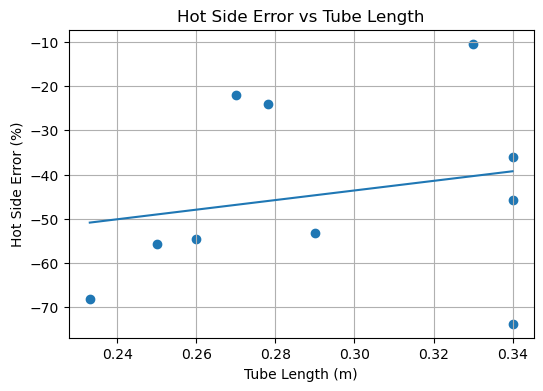

In [2]:
# -----------------------------
# Plot 1: Hot error vs tube length
# -----------------------------

plt.figure(figsize=(6,4))
plt.scatter(tube_lengths, hot_errors)

# Optional linear fit
m, c = np.polyfit(tube_lengths, hot_errors, 1)
xfit = np.linspace(min(tube_lengths), max(tube_lengths), 100)
plt.plot(xfit, m*xfit + c)

plt.xlabel("Tube Length (m)")
plt.ylabel("Hot Side Error (%)")
plt.title("Hot Side Error vs Tube Length")
plt.grid(True)

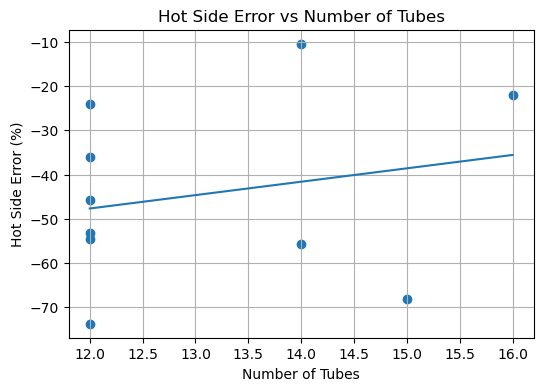

In [3]:
# -----------------------------
# Plot 2: Hot error vs number of tubes
# -----------------------------

plt.figure(figsize=(6,4))
plt.scatter(num_tubes, hot_errors)

m, c = np.polyfit(num_tubes, hot_errors, 1)
xfit = np.linspace(min(num_tubes), max(num_tubes), 100)
plt.plot(xfit, m*xfit + c)

plt.xlabel("Number of Tubes")
plt.ylabel("Hot Side Error (%)")
plt.title("Hot Side Error vs Number of Tubes")
plt.grid(True)

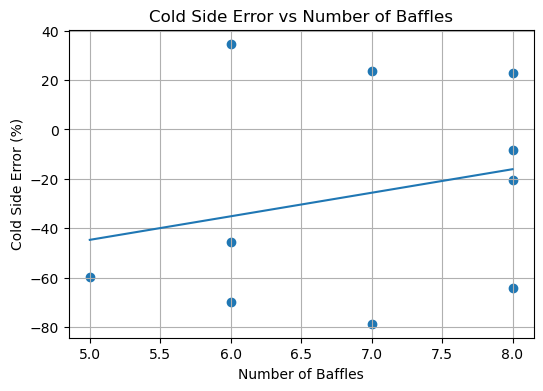

In [4]:
# -----------------------------
# Plot 3: Cold error vs number of baffles
# -----------------------------

plt.figure(figsize=(6,4))
plt.scatter(num_baffles, cold_errors)

m, c = np.polyfit(num_baffles, cold_errors, 1)
xfit = np.linspace(min(num_baffles), max(num_baffles), 100)
plt.plot(xfit, m*xfit + c)

plt.xlabel("Number of Baffles")
plt.ylabel("Cold Side Error (%)")
plt.title("Cold Side Error vs Number of Baffles")
plt.grid(True)